In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d import Axes3D

from DataGeneration import theta_time_evolution

plt.rcParams.update({'font.size': 12})

In [2]:
import tensorflow
print(tensorflow.__version__)

2.20.0


In [3]:
root = "C:\\Users\\tadej\\Desktop\\STUDIJ\\mag-2.letnik\\PSUF\\PSUF3\\data\\DataK\\"
path_Kvalues = root + "Kvalues.npy"
path_theta0 = root + "theta0.npy"
path_I500_n0 = root + "intensity500noise0.npy"
path_I500_n100 = root + "intensity500noise100.npy"
path_I505_n0 = root + "intensity505noise0.npy"
path_I505_n100 = root + "intensity505noise100.npy"
path_I700_n0 = root + "intensity700noise0.npy"
path_I700_n100 = root + "intensity700noise100.npy"
path_I900_n0 = root + "intensity900noise0.npy"
path_I900_n100 = root + "intensity900noise100.npy"

Kvalues = np.load(path_Kvalues)
theta0 = np.load(path_theta0)
I500_n0 = np.load(path_I500_n0)
I500_n100 = np.load(path_I500_n100)
I505_n0 = np.load(path_I505_n0)
I505_n100 = np.load(path_I505_n100)
I700_n0 = np.load(path_I700_n0)
I700_n100 = np.load(path_I700_n100)
I900_n0 = np.load(path_I900_n0)
I900_n100 = np.load(path_I900_n100)

In [4]:
print(np.shape(Kvalues))
print(np.shape(theta0))
print(np.shape(I500_n0))
print(np.shape(I900_n0))

(100000,)
(100000, 200)
(100000, 400)
(100000, 400)


- Histogram vrednosti K

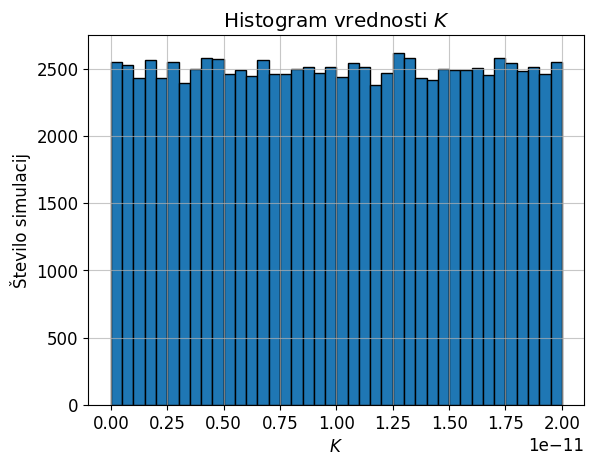

In [5]:
plt.hist(Kvalues, bins=40, edgecolor='black')
plt.xlabel(r'$K$')
plt.ylabel('Število simulacij')
plt.title(r'Histogram vrednosti $K$')
plt.grid(True, alpha=0.7)
plt.show()

In [6]:
print(np.min(Kvalues))
print(np.max(Kvalues))

1.937849993804974e-18
1.999990156099207e-11


- Povprečni profil intenzitete ter največja odstopanja

In [7]:
mean_I500_n0 = np.mean(I500_n0, axis=0)
distances = np.linalg.norm(I500_n0 - mean_I500_n0, axis=1)
n_top = 3
top_idx = np.argsort(distances)[-n_top:]
outliers_I = I500_n0[top_idx]
outliers_theta0 = theta0[top_idx]
outliers_Kvalues = Kvalues[top_idx]

C:\Users\tadej\AppData\Local\Temp\ipykernel_53920\261300721.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


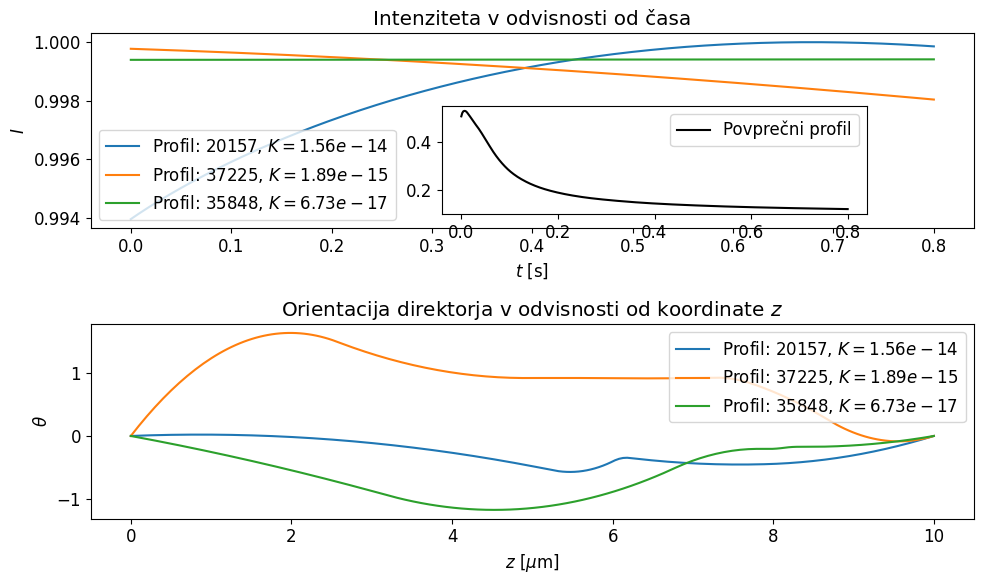

In [8]:
D = 10 * 1e-6 # Thicknes of layer in meters
n_z = np.shape(theta0[0])[0]
zs = np.linspace(0, D, n_z) * 1e6 # in um

T = 5 * 1e-6 * (240000 / 600)**2 # Time in seconds
n_t = np.shape(I500_n0[0])[0]
ts = np.linspace(0, T, n_t)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# axes[0].plot(ts, mean_I500_n0)

for i in range(len(outliers_I)):
    axes[0].plot(ts, outliers_I[i,:], label=rf"Profil: {top_idx[i]}, $K={outliers_Kvalues[i]:.2e}$")
    axes[1].plot(zs, outliers_theta0[i, :], label=rf"Profil: {top_idx[i]}, $K={outliers_Kvalues[i]:.2e}$")

ax_inset = fig.add_axes([0.45, 0.63, 0.425, 0.18])
ax_inset.plot(ts, mean_I500_n0, color='black', label='Povprečni profil')
ax_inset.legend()

axes[0].set_title('Intenziteta v odvisnosti od časa')
axes[0].set_xlabel(r'$t$ [s]')
axes[0].set_ylabel(r'$I$')
axes[0].legend(loc='lower left')

axes[1].set_title(r'Orientacija direktorja v odvisnosti od koordinate $z$')
axes[1].set_xlabel(r'$z$ [$\mu$m]')
axes[1].set_ylabel(r'$\theta$')
axes[1].legend(loc='upper right')

fig.tight_layout()

- Razvoj profila v času

In [9]:
K_mean = np.mean(Kvalues)

idx_min = np.argmin(Kvalues)
idx_low = np.argmin(np.abs(Kvalues - K_mean/2))
idx_mean = np.argmin(np.abs(Kvalues - K_mean))
idx_high = np.argmin(np.abs(Kvalues - 3*K_mean/2))
idx_max = np.argmax(Kvalues)

th0_min = theta0[idx_min]
K_min = Kvalues[idx_min]
th0_low = theta0[idx_low]
K_low = Kvalues[idx_low]
th0_mean = theta0[idx_mean]
K_mean = Kvalues[idx_mean]
th0_high = theta0[idx_high]
K_high = Kvalues[idx_high]
th0_max = theta0[idx_max]
K_max = Kvalues[idx_max]

gamma1 = 0.098

th_min = theta_time_evolution(th0_min, K_min/gamma1)
th_low = theta_time_evolution(th0_low, K_low/gamma1)
th_mean = theta_time_evolution(th0_mean, K_mean/gamma1)
th_high = theta_time_evolution(th0_high, K_high/gamma1)
th_max = theta_time_evolution(th0_max, K_max/gamma1)

C:\Users\tadej\AppData\Local\Temp\ipykernel_53920\1311432021.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


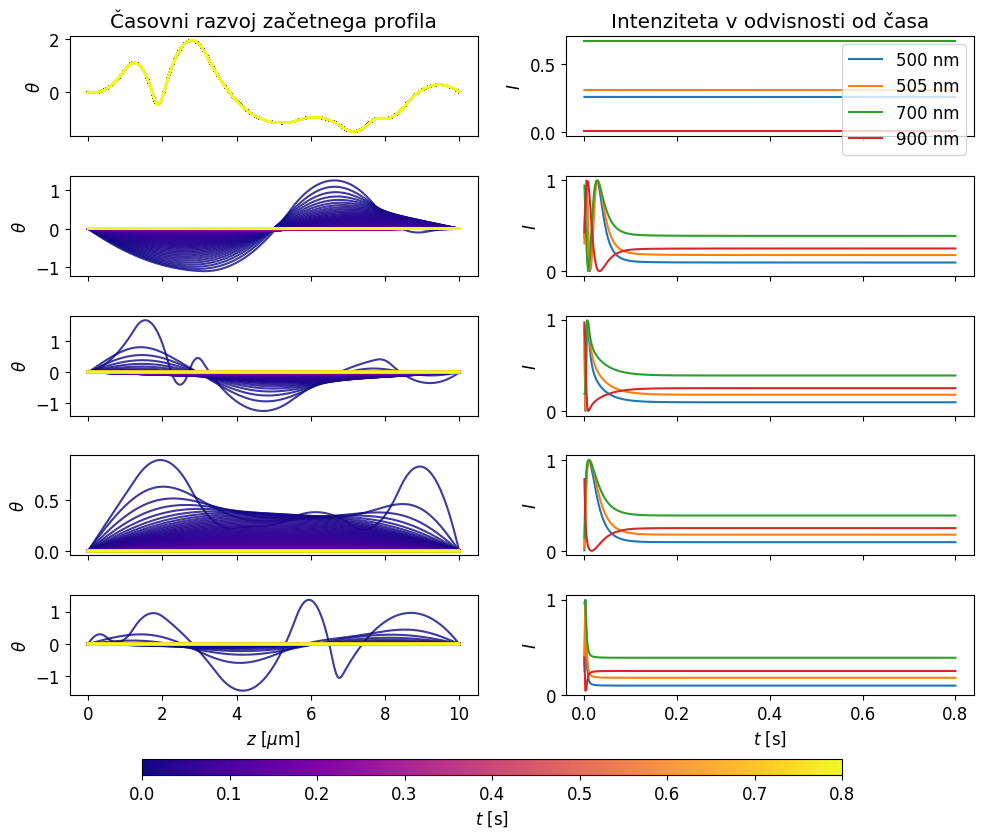

In [38]:
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0, 1, len(ts)))

fig, axes = plt.subplots(5, 2, figsize=(10, 8))

# nariši theta profile
for i, color in enumerate(colors):
    axes[0][0].plot(zs, th_min[i, :], color=color, alpha=0.8)
    axes[1][0].plot(zs, th_low[i, :], color=color, alpha=0.8)
    axes[2][0].plot(zs, th_mean[i, :], color=color, alpha=0.8)
    axes[3][0].plot(zs, th_high[i, :], color=color, alpha=0.8)
    axes[4][0].plot(zs, th_max[i, :], color=color, alpha=0.8)

# nariši I profile
Is = [I500_n0, I505_n0, I700_n0, I900_n0]
labels = ['500 nm', '505 nm', '700 nm', '900 nm']
for i, I in enumerate(Is):
    axes[0][1].plot(ts, I[idx_min, :], label=labels[i])
    axes[1][1].plot(ts, I[idx_low, :], label=labels[i])
    axes[2][1].plot(ts, I[idx_mean, :], label=labels[i])
    axes[3][1].plot(ts, I[idx_high, :], label=labels[i])
    axes[4][1].plot(ts, I[idx_max, :], label=labels[i])

axes[0][1].legend()

# horizontalna barvna lestvica spodaj z add_axes
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=ts[0], vmax=ts[-1]))

# [x0, y0, širina, višina] v figure koordinatah
cbar_ax = fig.add_axes([0.15, 0.02, 0.70, 0.02])  # spodaj, čez cel fig
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'$t$ [s]')

# nastavitve osi in naslovi
axes[0][0].set_title('Časovni razvoj začetnega profila')
axes[0][0].set_ylabel(r'$\theta$')
axes[0][1].set_title('Intenziteta v odvisnosti od časa')
axes[0][1].set_ylabel(r'$I$')

for i in range(0, 5):
    axes[i][0].set_ylabel(r'$\theta$')
    axes[i][1].set_ylabel(r'$I$')
    
    # skrij x oznake za vse, razen spodnjega reda
    if i < 4:  # vrstice 0 do 3
        axes[i][0].tick_params(labelbottom=False)
        axes[i][1].tick_params(labelbottom=False)

axes[4][0].set_xlabel(r'$z$ [$\mu$m]')
axes[4][1].set_xlabel(r'$t$ [s]')

fig.tight_layout()
fig.subplots_adjust(bottom=0.12, hspace=0.4) # prilagodi spodnjo
plt.show()

In [11]:
# fig = plt.figure(figsize=(10, 6))
# ax = fig.add_subplot(111, projection='3d')

# # Za vsak časovni korak narišemo profil kot 3D črto
# for i in range(n_t):
#     ax.plot(zs, ts[i] * np.ones(200), th[i, :], alpha=0.7)

# ax.set_xlabel('z')
# ax.set_ylabel('t')
# ax.set_zlabel('theta')

# ax.set_title(f'Time evolution of θ(z),  K = {K:.2e}')
# plt.tight_layout()
# plt.show()


- Konstrukcija nevronske mreže

In [42]:
Kmax = 20e-12

X = I500_n0
Y = Kvalues/Kmax

n = X.shape[0]
nt = int(0.9*n)

X_train = X[:nt]
X_test = X[nt:]

Y_train = Y[:nt]
Y_test = Y[nt:]

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(90000, 400)
(10000, 400)
(90000,)
(10000,)


In [43]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(200, activation='sigmoid', input_shape=(400,)))
model.add(tf.keras.layers.Dense(100, activation='sigmoid'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mean_squared_error'])

history = model.fit(X_train, Y_train, epochs=50, batch_size=25, validation_data=(X_test, Y_test), shuffle=True)

c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.1189 - mean_squared_error: 0.0289 - val_loss: 0.0859 - val_mean_squared_error: 0.0193
Epoch 2/50
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0825 - mean_squared_error: 0.0184 - val_loss: 0.0740 - val_mean_squared_error: 0.0167
Epoch 3/50
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0753 - mean_squared_error: 0.0171 - val_loss: 0.0840 - val_mean_squared_error: 0.0203
Epoch 4/50
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0713 - mean_squared_error: 0.0164 - val_loss: 0.0717 - val_mean_squared_error: 0.0152
Epoch 5/50
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0678 - mean_squared_error: 0.0157 - val_loss: 0.0702 - val_mean_squared_error: 0.0163
Epoch 6/50
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0640 - mean_squared_error: 0.0150 - val_loss: 0.0591 - val_mean_squared_error: 0.0136
Epoch 7/50
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0610 - mean_squared_error: 0.0144 - 